In [23]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
hartree2invcm = 219474.63

#dir = 'tetracene'
dir = 'dimer_opt'


# --- Read xyz and electron-phonon matrix ---
xyz = dir + '/' + dir + '.xyz'
h5file = dir + '/dft-lvc-out.h5'
with h5py.File(h5file, 'r') as f:
    ephmat = np.array(list(f['g_frontier_loc'])) * hartree2invcm 
    omega = np.array(list(f['omega'])) * hartree2invcm


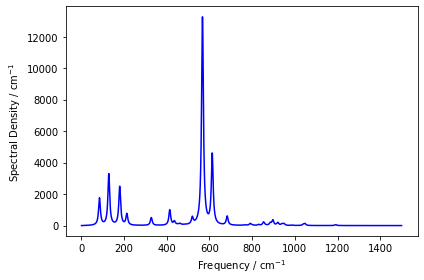

In [24]:
# --- Plot spectral density ---
hwhm = 5
wmax = 1500
fgrid = np.linspace(1,wmax,int(wmax))

# anti-symmetrized lorentzian lineshape
def lineshape(x, freq, hwhm):
    return 2 * x * freq * hwhm  / np.arctan(freq / hwhm) \
           / ((x-freq)**2 + hwhm**2) / ((x+freq)**2 + hwhm**2)

jgrid = np.zeros(fgrid.shape)

for w,v in zip(omega,ephmat):
    jgrid += np.linalg.norm(v)**2 * lineshape(fgrid, w, hwhm)

plt.figure()
plt.plot(fgrid, jgrid, 'b-')
plt.xlabel(r'Frequency / cm$^{-1}$')
plt.ylabel(r'Spectral Density / cm$^{-1}$')
plt.tight_layout()
plt.show()

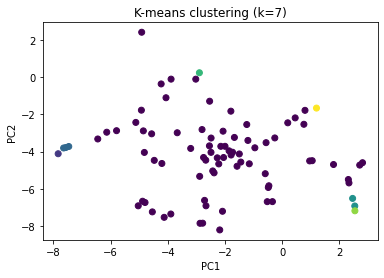

In [25]:
# --- el-ph coupling clustering ---
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


def cluster_and_plot(data, n_clusters=3, random_state=0):

    # --- k-means clustering ---
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    labels = kmeans.fit_predict(data)

    # --- dimensionality reduction to 2D ---
    #pca = PCA(n_components=2)
    #data_2d = pca.fit_transform(data)
    #centers_2d = pca.transform(kmeans.cluster_centers_)

    tsne = TSNE(n_components=2, perplexity=30, random_state=0)
    data_2d = tsne.fit_transform(data)
    #centers_2d = tsne.fit_transform(kmeans.cluster_centers_)

    # --- plotting ---
    plt.figure()
    scatter = plt.scatter(data_2d[:, 0], data_2d[:, 1], c=labels)
    #plt.scatter(centers_2d[:, 0], centers_2d[:, 1], marker='x', s=200)

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"K-means clustering (k={n_clusters})")

    plt.show()


data = ephmat.reshape(ephmat.shape[0], ephmat.shape[1]*ephmat.shape[2])
#for i in range(data.shape[0]):
#    data[i] = data[i] / np.linalg.norm(data[i])

cluster_and_plot(data, n_clusters=7)
